# <center>**IROS**<center>

**Libraries**

In [1]:
import numpy as np
import mbloodmoon.iros_management as iros

from mbloodmoon.mask import decode, count, variance, snratio
from mbloodmoon.images import upscale, compose
import mbloodmoon as bm

**IROS**

In [2]:
root_path = "/mnt/d/PhD_AASS/Coding/Images_fits/"
mask_file = root_path + "wfm_mask.fits"
simul_data = root_path + "iros_simulation_GC_LMC/20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb/"

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "reconstructed"

filepaths = bm.simulation_files(simul_data)
wfm = bm.codedmask(mask_file, upscale_x=3, upscale_y=1)
sdlA = bm.simulation(filepaths[cam_a][dataset])
sdlB = bm.simulation(filepaths[cam_b][dataset])

max_iterations = 25
snr_threshold = 5

n_test = 1

sdls = (sdlA, sdlB)
detectors = tuple(count(wfm, sdl.data)[0] for sdl in sdls)
variances = tuple(variance(wfm, d) for d in detectors)


wfm_WCS = bm.codedmask(mask_file, upscale_x=3, upscale_y=5)
wcs_fit = tuple(iros.handle.fit_WCS(wfm_WCS, sdl) for sdl in sdls)

In [ ]:
names = tuple(root_path + f"sky_SIMUL_{cam.upper()}_{n_test}.fits" for cam in (cam_a, cam_b))
comp_name = root_path + f"composed_sky_SIMUL_{cam_a.upper()}_{cam_b.upper()}_{n_test}.fits"

skies_SIMUL = tuple(decode(wfm, d) for d in detectors)
snrs_SIMUL = tuple(snratio(sky, np.clip(var_, a_min=1, a_max=None)) for sky, var_ in zip(skies_SIMUL, variances))

ups_SIMULskies = tuple(upscale(sky, upscale_y=5)[1:-1, :] for sky in skies_SIMUL)
ups_SIMULsnrs = tuple(upscale(snr, upscale_y=5)[1:-1, :] for snr in snrs_SIMUL)

for res, snr, sdl, name, wcs in zip(ups_SIMULskies, ups_SIMULsnrs, sdls, names, wcs_fit):
    iros.save_sky(res, snr, sdl, name, wcs)

iros.save_sky(
    sky=compose(*ups_SIMULskies, strict=False)[0],
    snr=compose(*ups_SIMULsnrs, strict=False)[0],
    sdl=sdlA,
    save_to=comp_name,
    wcs=wcs_fit[0],
)

# Saving Sky...


 [astropy.io.fits.verify]


# Saving completed!
# Saving Sky...


# Saving completed!
# Saving Sky...
# Saving completed!


In [3]:
iros_output_name: str = root_path + f"iros_output{n_test}.fits"

try:
    iros_output = iros.load_iros_output(iros_output_name)
    
except FileNotFoundError:
    iros_output, residuals = iros.perform_iros(
        camerasID=(cam_a, cam_b),
        camera=wfm,
        sdl_camA=sdlA,
        sdl_camB=sdlB,
        max_iterations=15,
        snr_threshold=snr_threshold,
        dataset=dataset,
    )
    
    iros.save_iros_output(iros_output, mask_file, iros_output_name)

    names = tuple(root_path + f"skyres_IROS_{cam.upper()}_{n_test}.fits" for cam in (cam_a, cam_b))
    comp_name = root_path + f"composed_skyres_IROS_{cam_a.upper()}_{cam_b.upper()}_{n_test}.fits"
    snrs = tuple(bm.snratio(sky, np.clip(var_, a_min=1, a_max=None)) for sky, var_ in zip(residuals, variances))

    ups_skies = tuple(upscale(sky, upscale_y=5)[1:-1, :] for sky in residuals)
    ups_snrs = tuple(upscale(snr, upscale_y=5)[1:-1, :] for snr in snrs)

    for res, snr, sdl, name, wcs in zip(ups_skies, ups_snrs, sdls, names, wcs_fit):
        iros.save_sky(res, snr, sdl, name)
    
    iros.save_sky(
        sky=compose(*ups_skies, strict=False)[0],
        snr=compose(*ups_snrs, strict=False)[0],
        sdl=sdlA,
        save_to=comp_name,
        wcs=wcs_fit[0],
    )

## Computing stuff...
## Looping around the FOV...


15it [03:06, 12.40s/it]


# Saving data...
# Saving completed!
# Saving Sky...


 [astropy.io.fits.verify]


# Saving completed!
# Saving Sky...


# Saving completed!
# Saving Sky...


# Saving completed!


**Compute Parameters**

In [5]:
iros_data_name = root_path + f"iros_data{n_test}.fits"

try:
    iros_data = iros.load_iros_data(iros_data_name)

except FileNotFoundError:
    log = iros.gen_params_log((cam_a, cam_b))

    iros_data = iros.compute_params(
        iros_output=iros_output,
        camera=wfm,
        sdl_camA=sdlA,
        sdl_camB=sdlB,
        log=log,
    )

    # WARNING: the px position in this DB might not match with upscaled skies
    iros.save_iros_data(
        data=iros_data,
        mask_file=mask_file,
        sdls=(sdlA, sdlB),
        save_to=iros_data_name,
    )

# Saving data...
# Saving completed!


 [astropy.io.fits.verify]


**Catalog Comparison**

In [6]:
dataset_name = root_path + f"database{n_test}.fits"
names = tuple(root_path + f"skyres_IROS_{cam.upper()}{n_test}.fits" for cam in (cam_a, cam_b))
comp_name = root_path + f"composed_skyres_IROS_{cam_a.upper()}{cam_b.upper()}{n_test}.fits"

try:
    dataset = iros.load_iros_data(dataset_name)
    resA, res_snrA = iros.load_sky(names[0])
    resB, res_snrB = iros.load_sky(names[1])
    comp_res, comp_snr = iros.load_sky(comp_name)

except FileNotFoundError:
    catalogA = filepaths[cam_a]["sources"]
    catalogB = filepaths[cam_b]["sources"]
    
    # WARNING: source assignment relies only on catalog sources
    dataset = iros.compare_w_catalog(
        data=iros_data,
        catalogA=catalogA,
        catalogB=catalogB,
        camerasID=(cam_a, cam_b),
        min_flux=0.1,
    )

    iros.save_iros_data(
        data=dataset,
        mask_file=mask_file,
        sdls=(sdlA, sdlB),
        save_to=dataset_name,
    )

## Comparing with Catalogs...
## Successful comparison!
# Saving data...
# Saving completed!


**Plot for Skies and SNRs**

In [9]:
from mbloodmoon.images import upscale, compose

skyA = iros.make_sky(
    data=dataset,
    cameraID=cam_a,
    camera=wfm,
    background=None,
)

skyB = iros.make_sky(
    data=dataset,
    cameraID=cam_b,
    camera=wfm,
    background=None,
)

skyA_wbg = upscale(skyA, upscale_y=5)[1:-1, :] + ups_skies[0]
skyB_wbg = upscale(skyB, upscale_y=5)[1:-1, :] + ups_skies[1]

In [10]:
from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera
from mbloodmoon.mask import count, variance, snratio

def get_significance(
    skymap: np.array,
    sdl: SimulationDataLoader,
    camera: CodedMaskCamera,
) -> np.array:
    """Computes SNR for the given sky."""
    detector, _ = count(camera, sdl.data)
    var = variance(camera, detector)
    return snratio(skymap, np.clip(var, a_min=1, a_max=None))

snrA = get_significance(skyA, sdlA, wfm)
snrB = get_significance(skyB, sdlB, wfm)

snrA_wbg = upscale(snrA, upscale_y=5)[1:-1, :] + ups_snrs[0]
snrB_wbg = upscale(snrB, upscale_y=5)[1:-1, :] + ups_snrs[1]

In [11]:
names = tuple(root_path + f"sky_IROS_{cam.upper()}_{n_test}.fits" for cam in (cam_a, cam_b))
iros.save_sky(skyA_wbg, snrA_wbg, sdlA, save_to=names[0])
iros.save_sky(skyB_wbg, snrB_wbg, sdlB, save_to=names[1])

skycomp, _ = compose(skyA_wbg, skyB_wbg, strict=False)
snrcomp, _ = compose(snrA_wbg, snrB_wbg, strict=False)
iros.save_sky(skycomp, snrcomp, sdlA, save_to=root_path + f"skycomp_IROS_{cam_a.upper()}_{cam_b.upper()}_{n_test}.fits")

# Saving Sky...


 [astropy.io.fits.verify]


# Saving completed!
# Saving Sky...


# Saving completed!
# Saving Sky...
# Saving completed!


**Now the PLOTZ**

In [ ]:
skyA_wbg_plot = skyA_wbg.copy(); skyA_wbg_plot[skyA_wbg < 0] = 0

sources_posA = [
    (5*y, x) for y, x in zip(
        dataset["cam1a"]["y"]["data"],
        dataset["cam1a"]["x"]["data"],
    )
]

iros.plot_sky(
    sky=skyA_wbg_plot,
    title=f"Galactic Center {cam_a.upper()}",
    sources_ID=dataset["cam1a"]["catalog_name"]["data"],
    sources_pos=sources_posA,
    highlight_pos=True,
)

In [ ]:
skyB_wbg_plot = skyB_wbg.copy(); skyB_wbg_plot[skyB_wbg < 0] = 0

sources_posB = [
    (5*y, x) for y, x in zip(
        dataset["cam1b"]["y"]["data"],
        dataset["cam1b"]["x"]["data"],
    )
]

iros.plot_sky(
    sky=skyB_wbg_plot,
    title=f"Galactic Center {cam_b.upper()}",
    sources_ID=dataset["cam1b"]["catalog_name"]["data"],
    sources_pos=sources_posB,
    highlight_pos=True,
)

In [ ]:
skycomp_plot = skycomp.copy(); skycomp_plot[skycomp < 0] = 0

sources_posA = [
    (5*y, x) for y, x in zip(
        dataset["cam1a"]["y"]["data"],
        dataset["cam1a"]["x"]["data"],
    )
]

iros.plot_sky(
    sky=skycomp,
    title=f"Galactic Center {cam_a.upper()}-{cam_b.upper()} composition",
    sources_ID=dataset["cam1a"]["catalog_name"]["data"],
    sources_pos=sources_posA,
    highlight_pos=False,
)

In [ ]:
snrA_wbg_plot = snrA_wbg.copy(); snrA_wbg_plot[snrA_wbg < 0] = 0

iros.plot_sky(
    sky=snrA_wbg_plot,
    title=f"Galactic Center SNR {cam_a.upper()}",
    sources_ID=dataset["cam1a"]["catalog_name"]["data"],
    sources_pos=sources_posA,
    highlight_pos=True,
)

In [ ]:
snrB_wbg_plot = snrB_wbg.copy(); snrB_wbg_plot[snrB_wbg < 0] = 0

iros.plot_sky(
    sky=snrB_wbg_plot,
    title=f"Galactic Center SNR {cam_b.upper()}",
    sources_ID=dataset["cam1b"]["catalog_name"]["data"],
    sources_pos=sources_posB,
    highlight_pos=True,
)

In [ ]:
snrcomp_plot = snrcomp.copy(); snrcomp_plot[snrcomp < 0] = 0

sources_posA = [
    (5*y, x) for y, x in zip(
        dataset["cam1a"]["y"]["data"],
        dataset["cam1a"]["x"]["data"],
    )
]

iros.plot_sky(
    sky=snrcomp_plot,
    title=f"Galactic Center {cam_a.upper()}-{cam_b.upper()} composition",
    sources_ID=dataset["cam1a"]["catalog_name"]["data"],
    sources_pos=sources_posA,
    highlight_pos=False,
)

<br>

<br>

<br>

**Let's check the Statistics of the Counts**

In [4]:
import numpy as np
from pandas import DataFrame

from mbloodmoon.iros_management.analyze import dict2df
from mbloodmoon.io import SimulationDataLoader

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [5]:
def iros_radec_accuracy(
    data: dict,
    catalogs: tuple[np.recarray],
    sigma: int | float,
) -> tuple[list[tuple[str, bool]], tuple[float]]:
    """
    Analysis of the IROS reconstruction RA/DEC estimates and
    comparison with catalogs coordinates.
    """
    errboxes = ([], [])

    for cat, cameraID, errbox in zip(
        catalogs,
        data.keys(),
        errboxes,
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name, ra, dec, dra, ddec in zip(
            data[cameraID]["catalog_name"]["data"],
            data[cameraID]["ra"]["data"],
            data[cameraID]["dec"]["data"],
            data[cameraID]["dra"]["data"],
            data[cameraID]["ddec"]["data"],
        ):
            cat_source_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_source_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            errbox.append(
                int((np.abs(cat_source_ra - ra) < sigma*dra) and (np.abs(cat_source_dec - dec) < sigma*ddec)),
            )
    
    sources_in_box = {
        cameraID: {
            "sources": data[cameraID]["catalog_name"]["data"],
            "inbox": [bool(e) for e in errbox],
        }
        for cameraID, errbox in zip(data.keys(), errboxes)
    }
    accuracy = tuple(
        np.array(errbox).sum()*100/len(data[cameraID]["catalog_name"]["data"]) for errbox in errboxes
    )
    return sources_in_box, accuracy


sources_in_box, accuracy = iros_radec_accuracy(#_finecoord(
    data=dataset,
    catalogs=(catalogA, catalogB),
    sigma=5,
)

# Checking CAM1A...
# Checking CAM1B...


In [6]:
def iros_fluence(
    data: dict,
    sdls: tuple[SimulationDataLoader],
    catalogs: tuple[np.recarray],
) -> DataFrame:
    """
    Checks fluences.
    """
    db = {
        cameraID: {
            "sources": [],
            "optm_wrt_fits": [],
            "obs_wrt_fits": [],
            "sub_wrt_fits": [],
            "retrv_wrt_fits": [],
        }
        for cameraID in data.keys()
    }

    for sdl, cat, cameraID in zip(
        sdls, catalogs, data.keys(),
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name, f, of, sf, sp in zip(
            data[cameraID]["catalog_name"]["data"],
            data[cameraID]["fluence"]["data"],
            data[cameraID]["obs_fluence"]["data"],
            data[cameraID]["sub_fluence"]["data"],
            data[cameraID]["simulphotons"]["data"],
        ):
            cat_source_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_source_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            # conv float64 to float32
            total_phs_simulated = len(
                sdl.data[(np.abs(sdl.data["RA"] - cat_source_ra) < 1e-7) & (np.abs(sdl.data["DEC"] - cat_source_dec) < 1e-7)]
            )
            params = (
                name,
                f * 100 / total_phs_simulated,
                of * 100 / total_phs_simulated,
                sf * 100 / total_phs_simulated,
                sp * 100 / total_phs_simulated,
            )
            for key, param in zip(
                db[cameraID].keys(), params,
            ):
                db[cameraID][key].append(param)
    
    return dict2df(db)


df = iros_fluence(
    data=dataset,
    sdls=(sdlA, sdlB),
    catalogs=(catalogA, catalogB),
)

# Checking CAM1A...
# Checking CAM1B...


# Checking CAM1A...


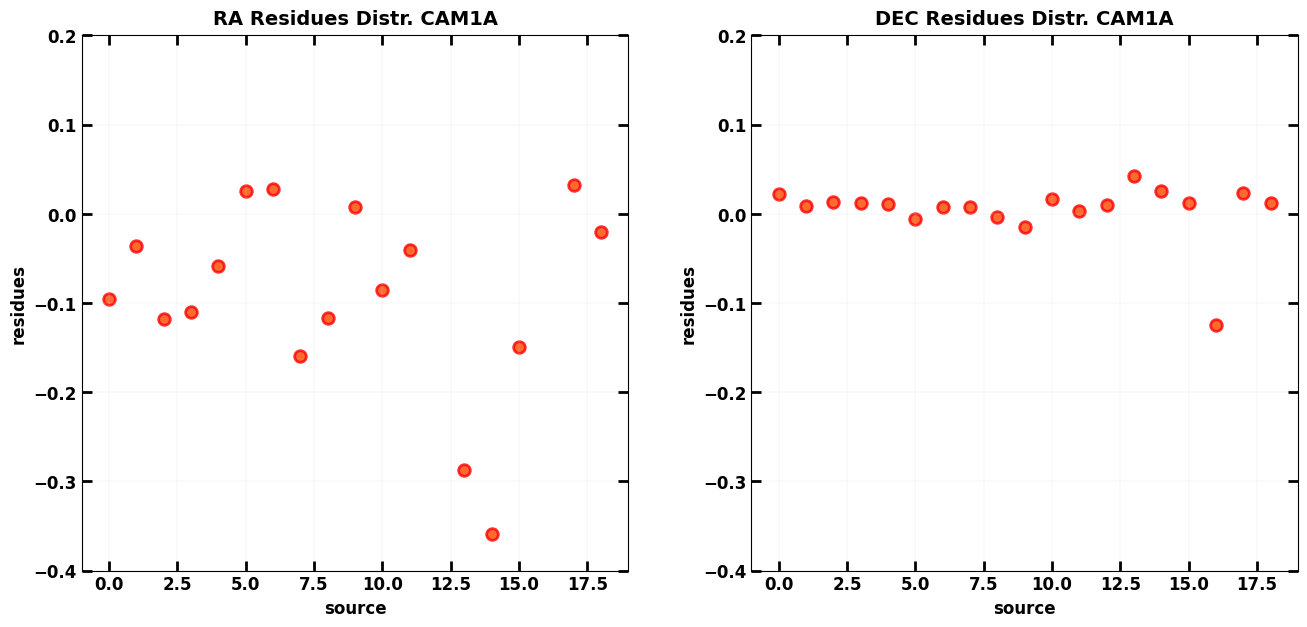

# Checking CAM1B...


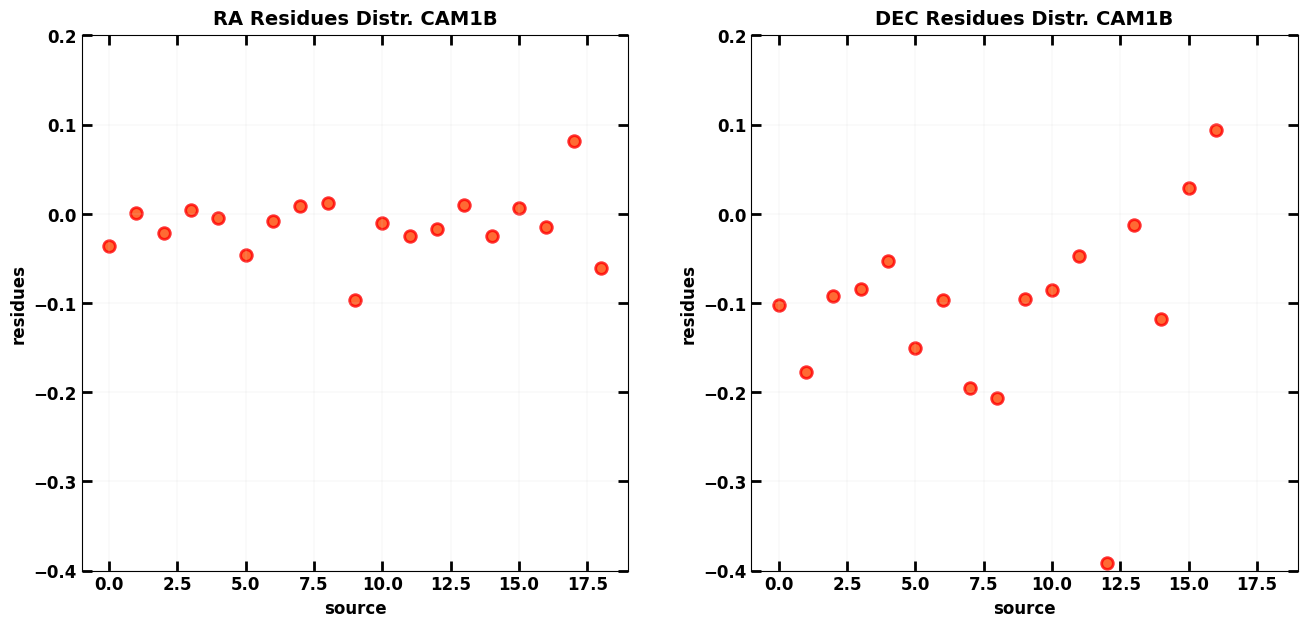

cam1a               cam1b          
      ra_res   dec_res    ra_res   dec_res
0  -0.095258  0.021686 -0.035914 -0.102609
1  -0.036065  0.008379  0.001122 -0.177428
2  -0.117501  0.013515 -0.021276 -0.092502
3  -0.110306  0.011937  0.004663 -0.084669
4  -0.059143  0.010600 -0.004434 -0.052663
5   0.025373 -0.006433 -0.046390 -0.149964
6   0.027499  0.007511 -0.008211 -0.096996
7  -0.159025  0.007495  0.008995 -0.195144
8  -0.116494 -0.004009  0.012501 -0.206933
9   0.007971 -0.014586 -0.097170 -0.095912
10 -0.085718  0.016770 -0.010595 -0.084990
11 -0.040533  0.002615 -0.024831 -0.047142
12 -0.790419  0.009689 -0.017410 -0.390990
13 -0.286776  0.042258  0.010093 -0.012674
14 -0.358483  0.025816 -0.024693 -0.117618
15 -0.148901  0.012237  0.006592  0.029367
16  0.837046 -0.125154 -0.014890  0.093608
17  0.032225  0.023193  0.081351 -0.584534
18 -0.020752  0.012113 -0.060799 -0.574008

In [8]:
from dummymoon import sequence_plot

def check_sources_res(
    data: dict,
    catalogs: tuple[np.recarray],
) -> DataFrame:
    """
    Check residues.
    """
    def source_res(
        catalog: np.recarray,
        source_name: str,
        ra: float,
        dec: float,
    ) -> float:
        """Computes the RA/DEC residues wrt catalog position."""
        cat_source_ra = catalog.data[catalog.data["NAME"] == source_name]["RA"][0]
        cat_source_dec = catalog.data[catalog.data["NAME"] == source_name]["DEC"][0]
        return ra - cat_source_ra, dec - cat_source_dec
    
    ra_res = ([], [])
    dec_res = ([], [])
        
    for idx, cameraID, cat in zip(
        (0, 1), data.keys(), catalogs,
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name, ra, dec in zip(
            data[cameraID]["catalog_name"]["data"],
            data[cameraID]["ra"]["data"],
            data[cameraID]["dec"]["data"],
        ):
            rra, rdec = source_res(cat, name, ra, dec)
            ra_res[idx].append(rra); dec_res[idx].append(rdec)
        sequence_plot(
            input_sequence=[ra_res[idx], dec_res[idx]],
            title=[e + f" Residues Distr. {cameraID.upper()}" for e in ["RA", "DEC"]],
            xlabel=["source"]*2,
            ylabel=["residues"]*2,
            style=["scatter"]*2,
            offsetx=[(-1, 1)]*2,
            offsety=[(-0.4, 0.2)]*2,
        )
    
    df = dict2df(
        {
            cameraID: {
                "ra_res": np.array(ra_res[idx]),
                "dec_res": np.array(dec_res[idx]),
            }
            for idx, cameraID in enumerate(data.keys())
        }
    )
    return df


check_sources_res(dataset, (catalogA, catalogB))

In [ ]:
def perform_iros(
    camerasID: tuple[str],
    camera: CodedMaskCamera,
    sdl_camA: SimulationDataLoader,
    sdl_camB: SimulationDataLoader,
    max_iterations: int = 25,
    snr_threshold: int | float = 5,
    dataset: Literal["detected", "reconstructed"] = "reconstructed",
) -> tuple[dict, tuple[np.array, np.array]]:
    """
    Runs the IROS (Iterative Removal of Sources) loop and stores the output.
    This function iteratively removes detected sources from the sky and updates 
    a log until either the maximum number of iterations is reached or the 
    SNR threshold is met.

    Args:
        camerasID (tuple[str]):
            Cameras of the WFM being processed.
        camera (CodedMaskCamera):
            CodedMaskCamera instance used for imaging and reconstruction.
        sdl_camA (SimulationDataLoader):
            SimulationDataLoader instance for camera A.
        sdl_camB (SimulationDataLoader):
            SimulationDataLoader instance for camera B.
        max_iterations (int, optional (default=25)):
            Maximum number of iterations for the IROS loop.
        snr_threshold (int | float, optional (default=5)):
            Minimum SNR value required to continue the iterative source removal process.
        dataset (Literal["detected", "reconstructed"], optional (default="reconstructed")):
            Specifies which dataset to use. 
            - "detected": Dataset with the simulated photons prior to reconstruction.
            - "reconstructed": Dataset with the position-reconstructed photons.

    Returns:
        output (tuple):
            - log_output (dict): Log with metadata and results from IROS.
            - residuals (tuple[np.array, np.array]): Sky residuals after IROS.
    """
    def compute_snratios(
        skymaps: tuple[np.ndarray, np.ndarray],
        varmaps: tuple[np.ndarray, np.ndarray],
    ) -> tuple[np.ndarray, np.ndarray]:
        """Computes skies SNR."""
        snrs = tuple(snratio(sky, np.clip(var_, a_min=1, a_max=None)) for sky, var_ in zip(skymaps, varmaps))
        return snrs

    def init_log() -> dict:
        """Initializes the log dict structure."""
        init_keys = {
            "shiftx": [], "shifty": [], "fluence": [],
            "snr": [], "obs_counts": [], "sub_counts": [],
        }
        return {camera: deepcopy(init_keys) for camera in camerasID}
    
    def store_output(
        rec_source: tuple[tuple],
        significances: tuple[float],
        obs_counts: tuple[float],
        sub_counts: tuple[float],
    ) -> None:
        """Stores sources info into log."""
        for idx, camera in enumerate(camerasID):
            params = [
                *rec_source[idx], significances[idx], obs_counts[idx], sub_counts[idx],
            ]
            for key, p in zip(log_keys, params):
                log_output[camera][key].append(p)
    
    def data2array() -> None:
        """Converts the log lists in arrays."""
        for camera in camerasID:
            for key in log_keys:
                if not isinstance(log_output[camera][key], np.ndarray):
                    log_output[camera][key] = np.asarray(log_output[camera][key])
    
    print("## Computing stuff...")
    log_output = init_log()
    log_keys = list(log_output[camerasID[0]].keys())
    detectors = tuple(count(camera, sdl.data)[0] for sdl in [sdl_camA, sdl_camB])
    variances = tuple(variance(camera, d) for d in detectors)
    skies = tuple(decode(camera, d) for d in detectors)
    skies_max = [tuple(np.max(sky) for sky in skies)]
    skies = [skies]
    snrs = [compute_snratios(skies, variances)]

    loop = iros(
        camera=camera,
        sdl_cam1a=sdl_camA,
        sdl_cam1b=sdl_camB,
        max_iterations=max_iterations,
        snr_threshold=snr_threshold,
        dataset=dataset,
    )

    print("## Looping around the FOV...")
    for sources, residuals in tqdm(loop):
        skies.append(residuals)
        snrs.append(compute_snratios(residuals, variances))
        skies_max.append(tuple(np.max(r) for r in residuals))
        significances = (-999, -999)
        obs_counts = skies_max[0]
        sub_counts = tuple(s.max() - r[*argmax(s)] for s, r in zip(skies[0], skies[1]))
        skies.pop(0); skies_max.pop(0); snrs.pop(0)
        store_output(sources, significances, obs_counts, sub_counts)

        for idx, s in enumerate(sources):
            print(
                f"Source output: {s}\n"
                f"Shifts indexes: {shift2pos(camera, *s[:-1])}\n"
                f"SNR[0][{idx}] shape: {snrs[0][idx][*shift2pos(camera, *s[:-1])]}"
            )
        #tuple(snrs[0][idx][*shift2pos(camera, *s[:-1])] for idx, s in enumerate(sources))

    data2array()
    return log_output, residuals